In [1]:
from scipy import signal as signal
from sklearn.decomposition import PCA

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

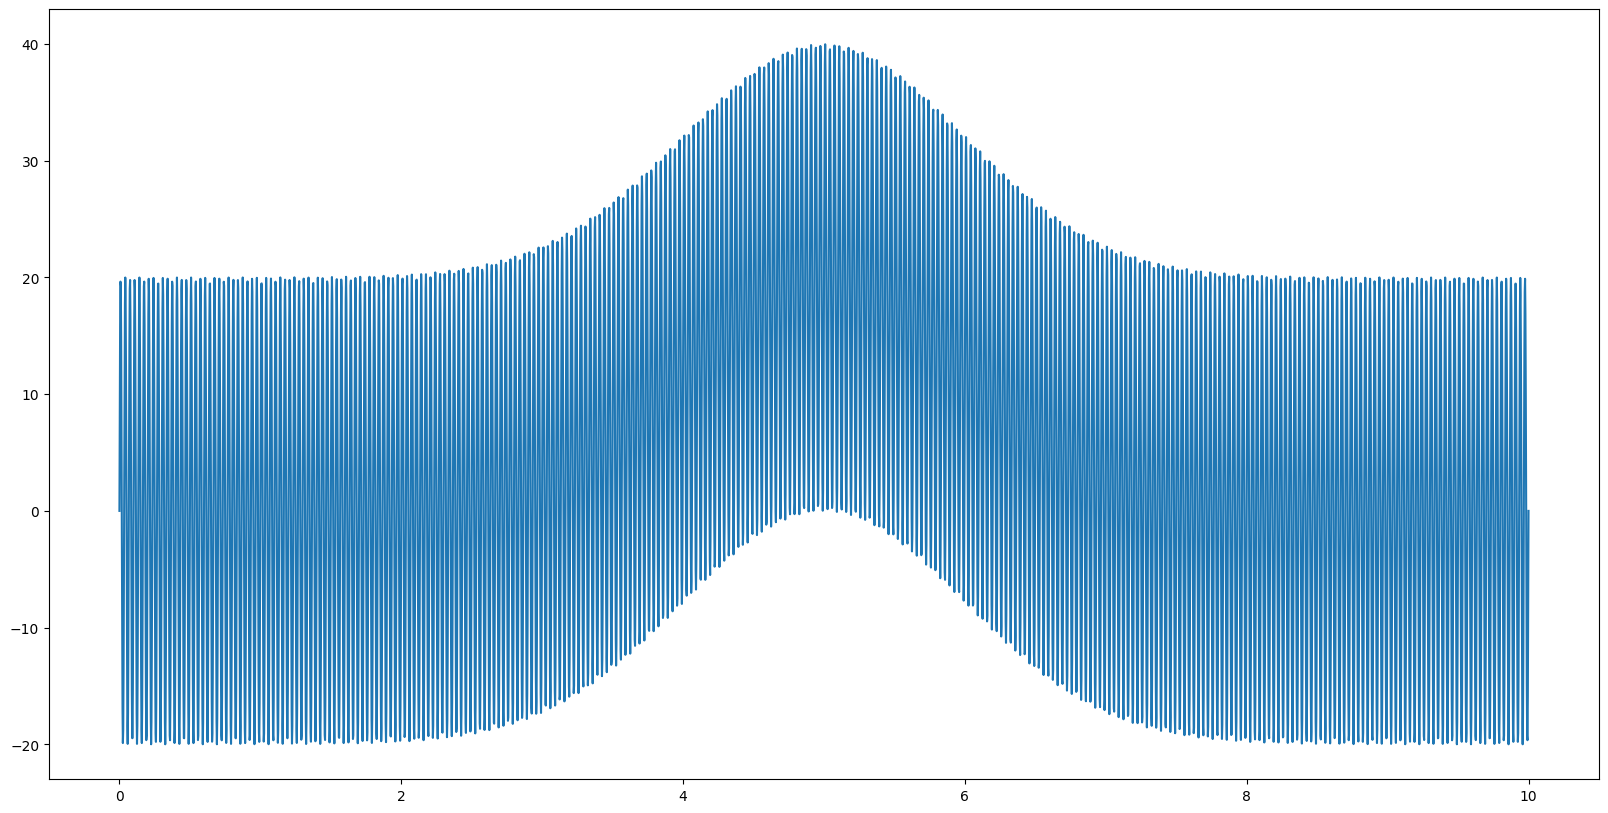

In [25]:
tin = 0
tfi = 10
n = 4092
t = np.linspace(tin,tfi,n)

fs = (n-1)/(tfi-tin)
f = 30
y = 20*np.exp(-0.5*np.power(t-5,2))+20*np.sin(2*np.pi*f*t)
plt.figure(figsize=(20,10))
plt.plot(t,y)

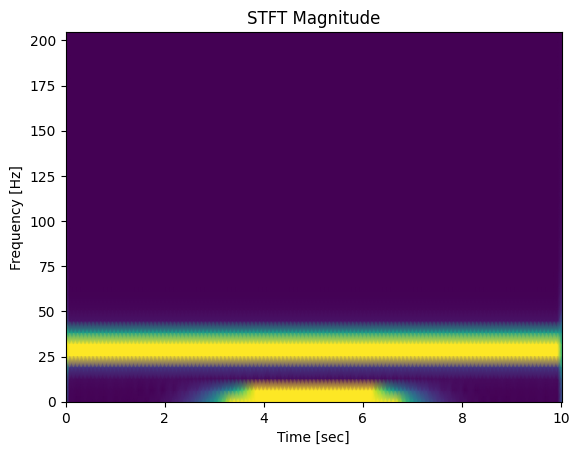

In [26]:
f, t, Zxx = signal.stft(y, fs, nperseg=64)

plt.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=5, shading='gouraud')

plt.title('STFT Magnitude')

plt.ylabel('Frequency [Hz]')

plt.xlabel('Time [sec]')

plt.show()

In [71]:
data = pd.DataFrame(np.abs(Zxx)).T

Z = (data-data.mean())/data.std()
model = PCA(n_components=2)
newModel = pd.DataFrame(model.fit_transform(Z))

model.explained_variance_ratio_.cumsum()

array([0.90647479, 0.96685692])

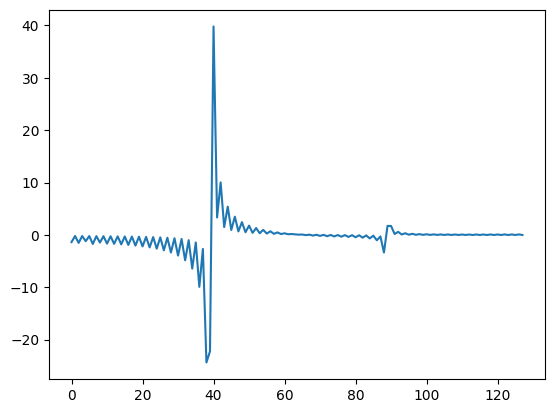

In [72]:
_,yinv = signal.istft((pd.DataFrame(Zxx).T @ model.components_.T).to_numpy(),fs)
plt.plot(yinv)